# 08 · Scale and cost: preview, several analyses, one upload

**Questions:** what does a run cost before I send it? How do I run several analyses
on one site fast? What does a larger area look like?

One tile is one billed job. The SDK cuts an area into tiles of 512 m (sun, light and
comfort analyses) or into overlapping wind tiles with a step of 256 m. It uploads the
geometry of each tile one time, and every analysis on the same tile grid uses that upload.

Site: the centre of Rotterdam, public buildings and trees.

In [1]:
import contextlib
import io
import logging
import os
import time

import matplotlib.pyplot as plt
import pandas as pd

from infrared_sdk import InfraredClient, SolarModelRequest, SolarRadiationModelRequest, SvfModelRequest
from infrared_sdk.analyses.types import AnalysesName, BaseAnalysisPayload
from infrared_sdk.models import Location, TimePeriod

import ir_plot as irp

os.environ["INFRARED_QUIET"] = "1"  # no progress lines
logging.getLogger("infrared_sdk").setLevel(logging.ERROR)  # no start-up notes
client = InfraredClient()  # reads INFRARED_API_KEY

lon, lat = 4.4777, 51.9225
polygon = irp.site(lon, lat, width_m=900)
buildings = irp.cached_object("rotterdam-buildings", lambda: client.buildings.get_area(polygon))
trees = irp.cached_object("rotterdam-trees", lambda: client.vegetation.get_area(polygon))
print(f"{len(buildings.buildings)} buildings, {trees.total_trees} trees")

1595 buildings, 2732 trees


## 1. Count before you run

`preview_area` is free and local: it sends no job. Give the analysis, because it selects
the tile grid. Price from `would_bill_jobs`. One call prices one analysis.

In [2]:
analyses = ["sky-view-factors", "solar-radiation", "direct-sun-hours",
            "thermal-comfort-index", "wind-speed", "pedestrian-wind-comfort"]
rows = []
for name in analyses:
    p = client.preview_area(polygon, analysis_type=name)
    rows.append({"analysis": name, "tiles": p.tile_count, "jobs": p.would_bill_jobs,
                 "tokens": p.estimated_cost_tokens})
pd.DataFrame(rows).set_index("analysis")

,tiles,jobs,tokens
analysis,,,
sky-view-factors,4,4,40
solar-radiation,4,4,40
direct-sun-hours,4,4,40
thermal-comfort-index,4,4,40
wind-speed,16,16,160
pedestrian-wind-comfort,16,16,160


**What you see:** the four sun and comfort analyses need 4 tiles for 900 m × 900 m.
The wind analyses need about four times more, because their tiles overlap by half.

## 2. Three analyses on one geometry

Sky view factor, solar radiation and direct sun hours use the same tile grid.
We run the first one alone, then the other two in one call, and count the geometry uploads.
The SDK prints one `s3_put` progress line for each upload; we count these lines and do not show them.

In [3]:
location = Location(latitude=lat, longitude=lon)
summer = TimePeriod(start_month=6, start_day=1, start_hour=6, end_month=8, end_day=31, end_hour=20)
station = client.weather.get_weather_file_from_location(lat=lat, lon=lon)[0]
hours = client.weather.filter_weather_data(identifier=station["uuid"], time_period=summer)

svf = SvfModelRequest(analysis_type=AnalysesName.sky_view_factors)
radiation = SolarRadiationModelRequest.from_weatherfile_payload(
    payload=BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation),
    location=location, time_period=summer, weather_data=hours)
sun_hours = SolarModelRequest(analysis_type=AnalysesName.direct_sun_hours,
                              latitude=lat, longitude=lon, time_period=summer)

def measured_run(payload) -> dict:
    """Run, and count the uploads and the seconds."""
    os.environ.pop("INFRARED_QUIET")  # we need the progress lines to count uploads
    log, start = io.StringIO(), time.perf_counter()
    try:
        with contextlib.redirect_stdout(log):
            result = client.run_area_and_wait(payload, polygon, buildings=buildings,
                                              vegetation=trees.features)
    finally:
        os.environ["INFRARED_QUIET"] = "1"
    results = result if isinstance(result, list) else [result]
    return {"grids": [irp.Grid.of(r) for r in results], "jobs": sum(r.total_jobs for r in results),
            "uploads": log.getvalue().count("s3_put ok"), "seconds": time.perf_counter() - start}

first = irp.cached_object("rotterdam-run-svf", lambda: measured_run(svf))
second = irp.cached_object("rotterdam-run-solar", lambda: measured_run([radiation, sun_hours]))
pd.DataFrame([
    {"run": "1: sky view factor", **{k: first[k] for k in ("jobs", "uploads")},
     "seconds": round(first["seconds"], 1)},
    {"run": "2: solar radiation + sun hours", **{k: second[k] for k in ("jobs", "uploads")},
     "seconds": round(second["seconds"], 1)},
]).set_index("run")

,jobs,uploads,seconds
run,,,
1: sky view factor,4,4,3.4
2: solar radiation + sun hours,8,0,8.4


**What you see:** the first run uploads the geometry of each of its 4 tiles. The second
run sends 8 jobs and uploads nothing: it uses the uploads of the first run. The job count,
and so the cost, stays the same. The reuse saves upload time and data.

## 3. The three maps

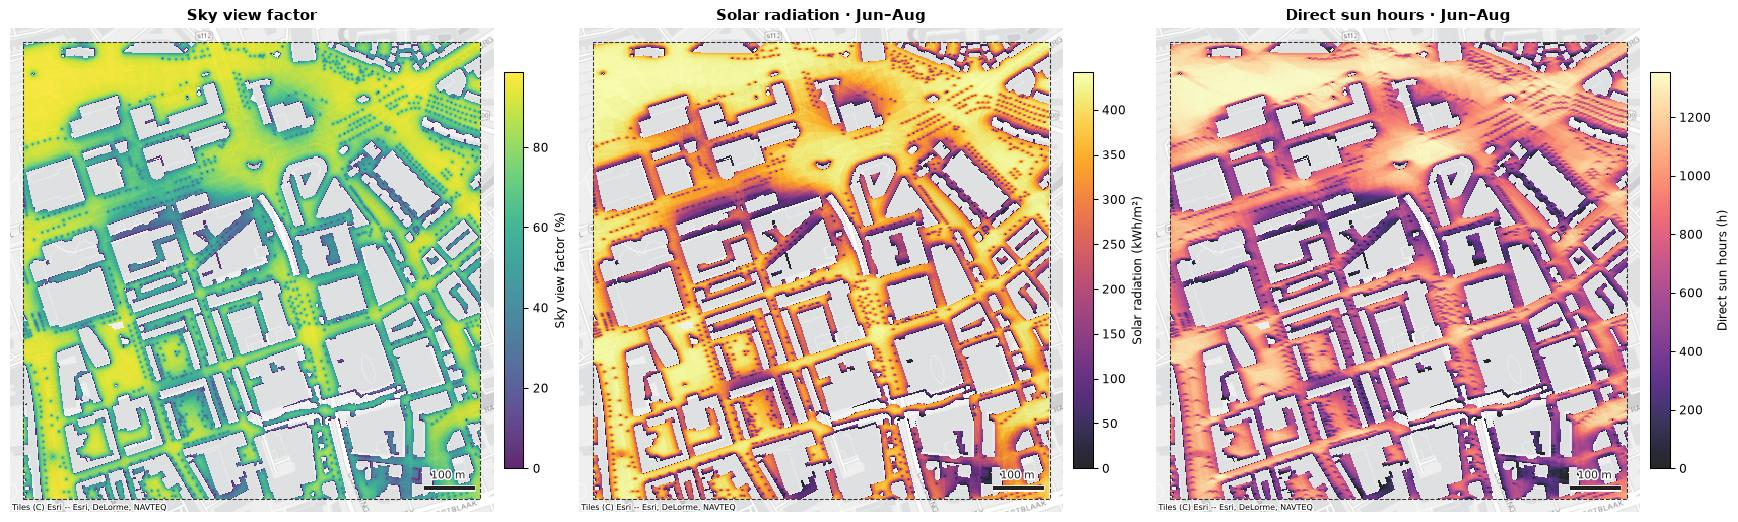

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), layout="constrained")
titles = ["Sky view factor", "Solar radiation · Jun–Aug", "Direct sun hours · Jun–Aug"]
for ax, grid, title in zip(axes, first["grids"] + second["grids"], titles):
    irp.map_grid(grid, ax, polygon=polygon, title=title)
plt.show()

**What you see:** one geometry, three questions. The sky view factor is low in narrow
streets and under trees. Solar radiation and sun hours add the path of the sun: the ground
on the north side of each building gets much less sun than the ground on the south side.

## 4. A larger area

The same sky view factor on 2 km × 2 km: 16 tiles. The work grows with the tile count,
and the tiles run at the same time.

In [5]:
big = irp.site(lon, lat, width_m=2000)
big_buildings = irp.cached_object("rotterdam-big-buildings", lambda: client.buildings.get_area(big))
preview = client.preview_area(big, payload=svf)
print(f"{len(big_buildings.buildings)} buildings; {preview.tile_count} tiles, "
      f"{preview.would_bill_jobs} jobs, {preview.estimated_cost_tokens} tokens")

def timed():
    start = time.perf_counter()
    grid = irp.Grid.of(client.run_area_and_wait(svf, big, buildings=big_buildings))
    return {"grid": grid, "seconds": time.perf_counter() - start}

large = irp.cached_object("rotterdam-big-svf", timed)
print(f"run time {large['seconds']:.0f} s for {large['grid'].values.size / 1e6:.1f} million cells")

8393 buildings; 16 tiles, 16 jobs, 160 tokens
run time 6 s for 4.2 million cells


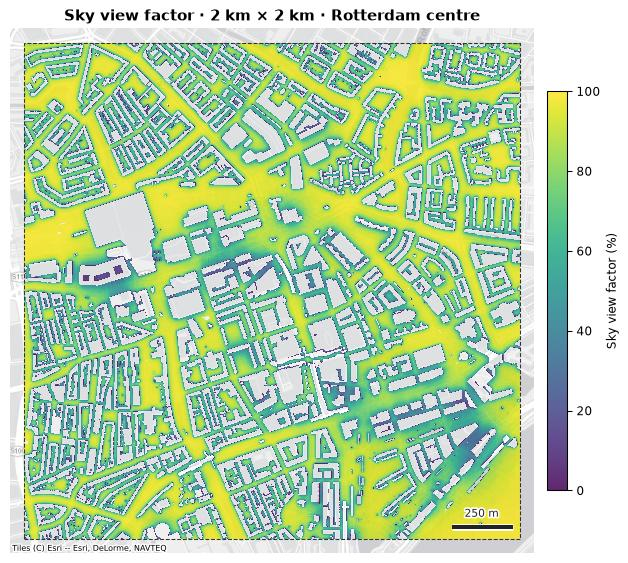

In [6]:
irp.map_grid(large["grid"], polygon=big, vmin=0, vmax=100, scale_m=250,
             title="Sky view factor · 2 km × 2 km · Rotterdam centre")
plt.show()

**What you see:** 16 tiles give one map with no visible tile edges. Wide roads and squares
are yellow (open sky); the dense blocks of the centre are dark.

## Cost rules in short

- One tile is one job. Price from `preview_area(...).would_bill_jobs`, one call per analysis.
- There is no result cache on the server: the same run again is billed again.
  Keep your own copy of the results (here: `irp.cached`).
- A failed tile is sent again with the same idempotency key: it is never billed two times.
- Guide, cost and retry: <https://infrared.city/docs/sdk/1.0/#cost-and-retry>